# Lab 6 - Classification trees


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

from collections import Counter
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.datasets import load_breast_cancer, load_iris, load_wine
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier


## Task 1 - classification tree on Breast Cancer


In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

settings = [
    {"criterion": "gini", "splitter": "best", "max_depth": None, "min_samples_split": 2},
    {"criterion": "entropy", "splitter": "best", "max_depth": None, "min_samples_split": 2},
    {"criterion": "gini", "splitter": "random", "max_depth": None, "min_samples_split": 2},
    {"criterion": "gini", "splitter": "best", "max_depth": 3, "min_samples_split": 2},
    {"criterion": "gini", "splitter": "best", "max_depth": None, "min_samples_split": 20},
]

rows = []
for params in settings:
    clf = DecisionTreeClassifier(random_state=RANDOM_STATE, **params).fit(X_train, y_train)
    rows.append({
        **params,
        "depth": clf.get_depth(),
        "leaves": clf.get_n_leaves(),
        "test_accuracy": accuracy_score(y_test, clf.predict(X_test)),
    })
rows


[{'criterion': 'gini',
  'splitter': 'best',
  'max_depth': None,
  'min_samples_split': 2,
  'depth': 6,
  'leaves': np.int64(16),
  'test_accuracy': 0.9181286549707602},
 {'criterion': 'entropy',
  'splitter': 'best',
  'max_depth': None,
  'min_samples_split': 2,
  'depth': 7,
  'leaves': np.int64(15),
  'test_accuracy': 0.9473684210526315},
 {'criterion': 'gini',
  'splitter': 'random',
  'max_depth': None,
  'min_samples_split': 2,
  'depth': 8,
  'leaves': np.int64(29),
  'test_accuracy': 0.9473684210526315},
 {'criterion': 'gini',
  'splitter': 'best',
  'max_depth': 3,
  'min_samples_split': 2,
  'depth': 3,
  'leaves': np.int64(7),
  'test_accuracy': 0.9239766081871345},
 {'criterion': 'gini',
  'splitter': 'best',
  'max_depth': None,
  'min_samples_split': 20,
  'depth': 5,
  'leaves': np.int64(9),
  'test_accuracy': 0.9239766081871345}]

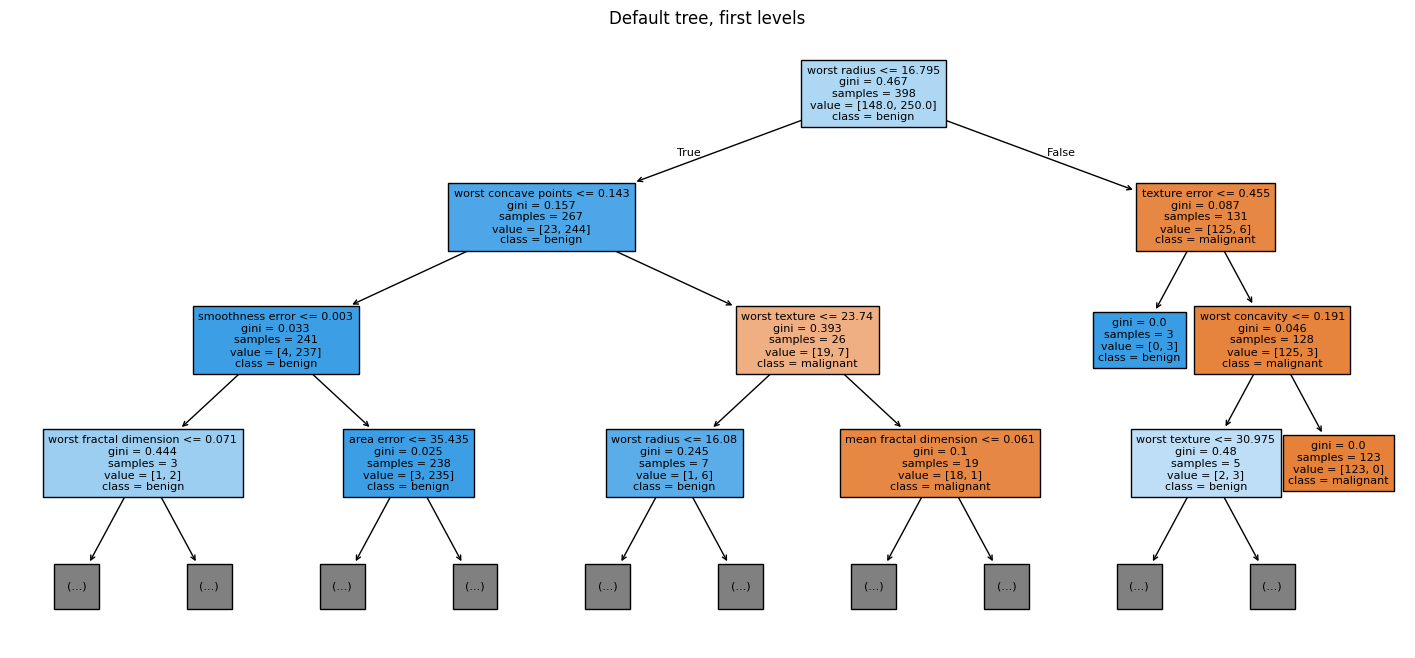

In [3]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
plt.figure(figsize=(18, 8))
plot_tree(tree, feature_names=data.feature_names, class_names=data.target_names, max_depth=3, filled=True, fontsize=8)
plt.title("Default tree, first levels")
plt.show()


The first splits are the highest impurity-reducing rules. For this dataset they usually involve radius, concavity, perimeter, or texture features that separate malignant and benign cases.


unpruned: {'depth': 6, 'leaves': np.int64(16), 'test_accuracy': 0.9181286549707602}
best pruned: {'ccp_alpha': np.float64(0.0029528585562200657), 'depth': 4, 'leaves': np.int64(9), 'test_accuracy': 0.935672514619883}


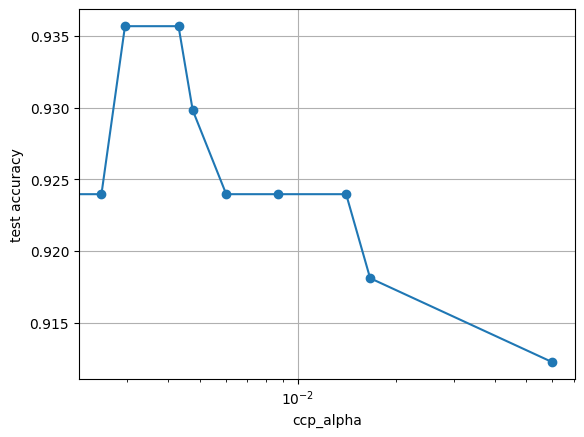

In [4]:
path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]
pruned = []
for alpha in alphas:
    clf = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha).fit(X_train, y_train)
    pruned.append((alpha, clf.get_depth(), clf.get_n_leaves(), accuracy_score(y_test, clf.predict(X_test))))

best = max(pruned, key=lambda item: item[3])
print("unpruned:", {"depth": tree.get_depth(), "leaves": tree.get_n_leaves(), "test_accuracy": accuracy_score(y_test, tree.predict(X_test))})
print("best pruned:", {"ccp_alpha": best[0], "depth": best[1], "leaves": best[2], "test_accuracy": best[3]})

plt.plot([p[0] for p in pruned], [p[3] for p in pruned], marker="o")
plt.xscale("log")
plt.xlabel("ccp_alpha")
plt.ylabel("test accuracy")
plt.grid(True)
plt.show()


## Task 2 - own bagging implementation


In [5]:
class SimpleBaggingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator=None, n_estimators=100, random_state=42):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        base = self.base_estimator or DecisionTreeClassifier()
        local_rng = np.random.default_rng(self.random_state)
        self.estimators_ = []
        n = len(y)
        for _ in range(self.n_estimators):
            idx = local_rng.integers(0, n, size=n)
            est = clone(base).fit(X[idx], y[idx])
            self.estimators_.append(est)
        return self

    def predict(self, X):
        preds = np.asarray([est.predict(X) for est in self.estimators_]).T
        return np.array([Counter(row).most_common(1)[0][0] for row in preds])


single = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
bag = SimpleBaggingClassifier(DecisionTreeClassifier(random_state=RANDOM_STATE), n_estimators=100, random_state=RANDOM_STATE).fit(X_train, y_train)
print("single tree accuracy:", accuracy_score(y_test, single.predict(X_test)))
print("bagging accuracy:", accuracy_score(y_test, bag.predict(X_test)))


single tree accuracy: 0.9181286549707602
bagging accuracy: 0.9590643274853801


Bagging reduces variance by averaging trees trained on bootstrap samples. It is especially useful for trees because small data changes can produce different split structures.


## Task 3 - single tree, bagging, random forest on three datasets


In [6]:
datasets = {
    "breast_cancer": load_breast_cancer(return_X_y=True),
    "iris": load_iris(return_X_y=True),
    "wine": load_wine(return_X_y=True),
}

results = []
for name, (X_ds, y_ds) in datasets.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.3, stratify=y_ds, random_state=RANDOM_STATE)
    methods = {
        "single_tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "bagging": SimpleBaggingClassifier(DecisionTreeClassifier(random_state=RANDOM_STATE), n_estimators=100, random_state=RANDOM_STATE),
        "random_forest": RandomForestClassifier(random_state=RANDOM_STATE),
    }
    for method, clf in methods.items():
        clf.fit(X_tr, y_tr)
        results.append({"dataset": name, "method": method, "accuracy": accuracy_score(y_te, clf.predict(X_te))})
results


[{'dataset': 'breast_cancer',
  'method': 'single_tree',
  'accuracy': 0.9181286549707602},
 {'dataset': 'breast_cancer',
  'method': 'bagging',
  'accuracy': 0.9590643274853801},
 {'dataset': 'breast_cancer',
  'method': 'random_forest',
  'accuracy': 0.935672514619883},
 {'dataset': 'iris', 'method': 'single_tree', 'accuracy': 0.9333333333333333},
 {'dataset': 'iris', 'method': 'bagging', 'accuracy': 0.8888888888888888},
 {'dataset': 'iris',
  'method': 'random_forest',
  'accuracy': 0.8888888888888888},
 {'dataset': 'wine', 'method': 'single_tree', 'accuracy': 0.9629629629629629},
 {'dataset': 'wine', 'method': 'bagging', 'accuracy': 1.0},
 {'dataset': 'wine', 'method': 'random_forest', 'accuracy': 1.0}]

Random forest usually improves over bagging by decorrelating trees through random feature subsampling. Bagging mainly reduces variance; a single tree is easier to interpret but less stable.
